In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy, kurtosis, skew
from scipy.stats import levy_stable
import json
import os


In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Hyperparameters
d = 100          # input and hidden dim
L = 20           # number of layers
N = 512          # batch size (number of input samples)
input_type = 'cauchy'  # options: 'gaussian', 'uniform', 'cauchy', 'pareto'

In [30]:
# Save per-neuron results to JSON
def save_levy_results_json(neuron_idx, results, out_path='levy_fits_nonorm.json'):
    if os.path.exists(out_path):
        with open(out_path, 'r') as f:
            all_results = json.load(f)
    else:
        all_results = {}
    all_results[str(neuron_idx)] = results
    with open(out_path, 'w') as f:
        json.dump(all_results, f, indent=2)
        
# Load existing results from file
def load_levy_results_json(out_path='levy_fits_nonorm.json'):
    if os.path.exists(out_path):
        with open(out_path, 'r') as f:
            return json.load(f)
    return {}


In [20]:
# Input distribution
def sample_input(N, d, input_type):
    if input_type == 'gaussian':
        return torch.randn(N, d)
    elif input_type == 'uniform':
        return torch.empty(N, d).uniform_(-1, 1)
    elif input_type == 'cauchy':
        return torch.from_numpy(cauchy.rvs(size=(N, d))).float()
    elif input_type == 'pareto':
        # Pareto distribution with shape parameter (alpha > 1)
        alpha = 2.0
        return torch.from_numpy((pareto.rvs(alpha, size=(N, d)) - 1.0)).float()  # shift to start near 0
    else:
        raise ValueError("Unknown input_type")

In [31]:
# Simple untrained deep network with LayerNorm and residuals
class DeepMLP(nn.Module):
    def __init__(self, d, L):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d, d) for _ in range(L)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(L)])

    def forward(self, x):
        activations = [x]
        for i, layer in enumerate(self.layers):
            x = x + F.relu(layer(x))#self.norms[i](x + F.leaky_relu(layer(x)))
            activations.append(x)
        return activations

In [32]:
# Run the experiment
x = sample_input(N, d, input_type)
model = DeepMLP(d, L)
with torch.no_grad():
    activations = model(x)

# Analyze increments
increments = [activations[i+1] - activations[i] for i in range(L)]

In [33]:
# Analyze and save results for multiple neurons
neuron_indices_to_analyze = [0,1]  # change or expand this list

for neuron_idx in neuron_indices_to_analyze:
    layer_fits = []
    for i, inc in enumerate(increments):
        try:
            alpha, beta, loc, scale = levy_stable.fit(inc[:, neuron_idx].numpy())
            layer_fits.append({
                'layer': i,
                'alpha': alpha,
                'beta': beta,
                'scale': scale
            })
        except Exception as e:
            layer_fits.append({
                'layer': i,
                'alpha': None,
                'beta': None,
                'scale': None,
                'error': str(e)
            })
    save_levy_results_json(neuron_idx, layer_fits)

c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\scipy\stats\_levy_stable\__init__.py:617: RuntimeWarning: divide by zero encountered in scalar divide
  nu_alpha = (p95 - p05) / (p75 - p25)
c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\scipy\stats\_levy_stable\__init__.py:617: RuntimeWarning: invalid value encountered in scalar divide
  nu_alpha = (p95 - p05) / (p75 - p25)
c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\scipy\stats\_levy_stable\__init__.py:618: RuntimeWarning: invalid value encountered in scalar divide
  nu_beta = (p95 + p05 - 2 * p50) / (p95 - p05)


In [34]:
# Load all saved results
saved_results = load_levy_results_json()

In [35]:
saved_results

{'0': [{'layer': 0,
   'alpha': 0.849870694135552,
   'beta': 0.9477586739878152,
   'scale': 0.0008259959815982672},
  {'layer': 1,
   'alpha': 0.9777381515710937,
   'beta': 0.9999874616470557,
   'scale': 0.09431502750515325},
  {'layer': 2,
   'alpha': 0.958205201962781,
   'beta': 0.9999960940282385,
   'scale': 0.9191753053419954},
  {'layer': 3,
   'alpha': None,
   'beta': None,
   'scale': None,
   'error': 'The function value at x=0.0002817472346705596 is NaN; solver cannot continue.'},
  {'layer': 4,
   'alpha': 0.7644629885046315,
   'beta': 0.9996215149909765,
   'scale': 4.839829222103037},
  {'layer': 5,
   'alpha': None,
   'beta': None,
   'scale': None,
   'error': 'The function value at x=0.000373286290364927 is NaN; solver cannot continue.'},
  {'layer': 6,
   'alpha': 0.5283177377465751,
   'beta': 0.986189113445352,
   'scale': 9.676589360559429e-27},
  {'layer': 7,
   'alpha': 0.7977927825810842,
   'beta': 0.9999976079083484,
   'scale': 7.712497495214171},
  {'


Loaded alpha values from file:
Neuron 0: [0.849870694135552, 0.9777381515710937, 0.958205201962781, 0.7644629885046315, 0.5283177377465751, 0.7977927825810842, 0.9298092910015407, 0.8667156232318671, 0.31183125760775054, 0.5329146697420069, 0.947832204053166, 0.8886590627482733, 0.9448957968740179]
Neuron 1: [0.9898368465054594, 0.9632376290655431, 0.9569181720397708, 0.946269020239614, 0.9665836950182944, 0.8759187959729327, 0.9092834409268173, 0.8416503751492587, 0.9142259114868234, 0.8417371057425422, 0.836755841658231, 0.8237927817716466, 0.811084646578655, 0.8880909868348131, 0.8909278641736676, 0.9250863733403376, 0.9259974839039147]


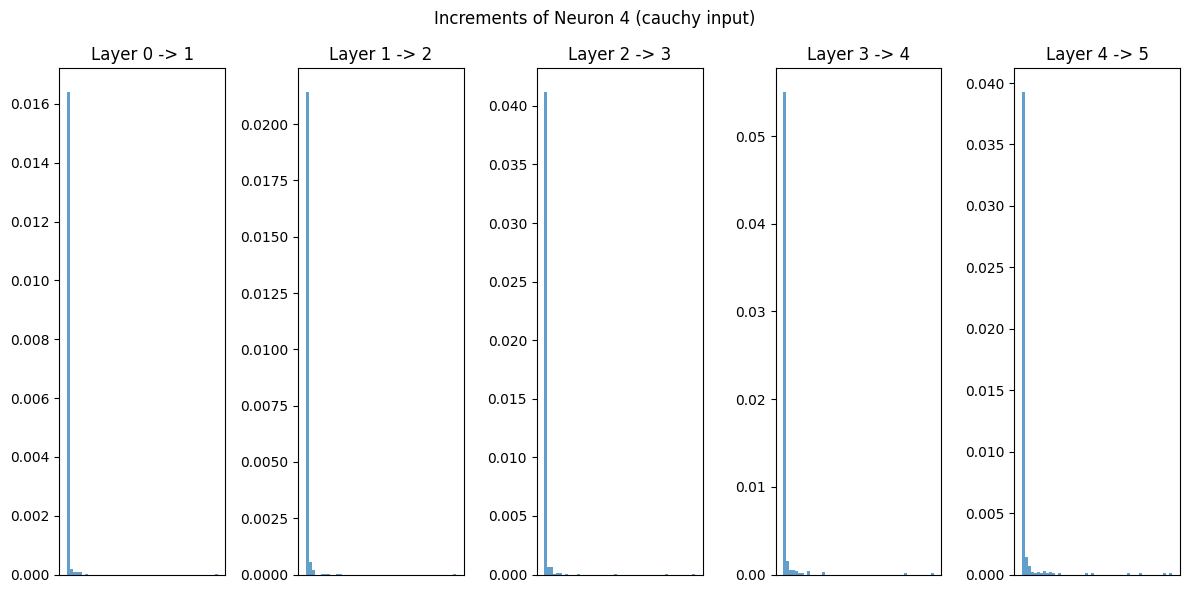

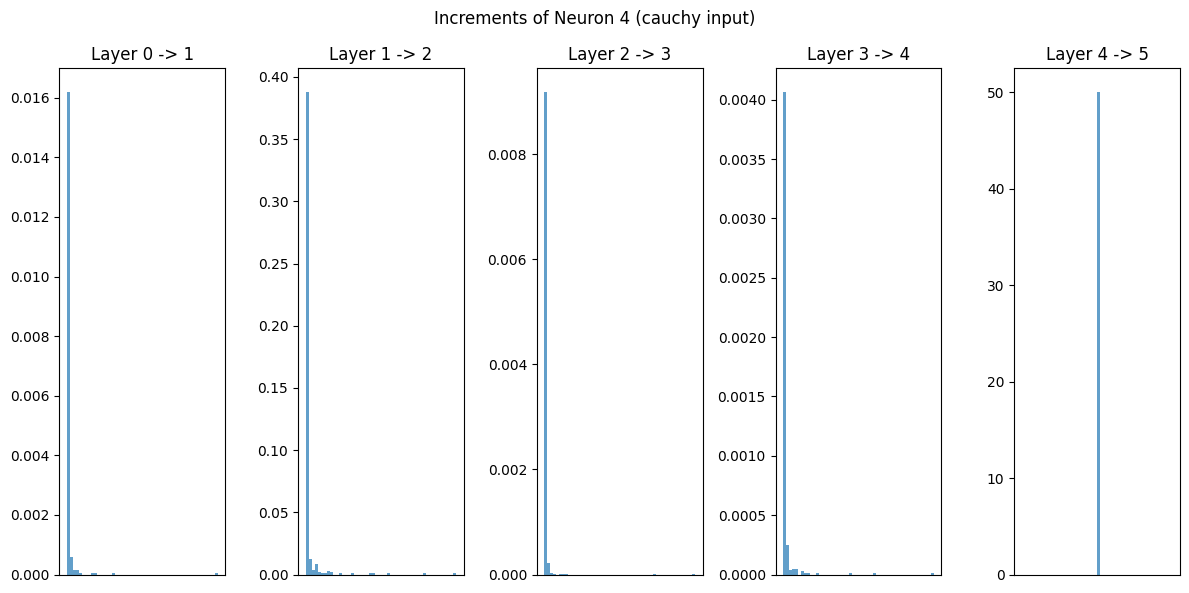

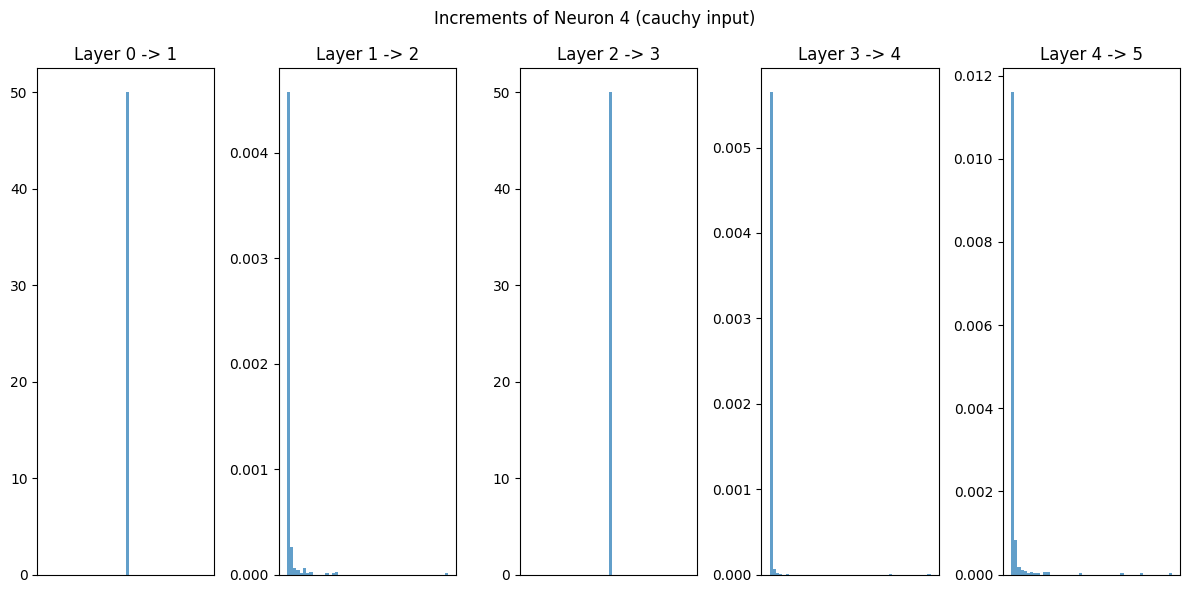

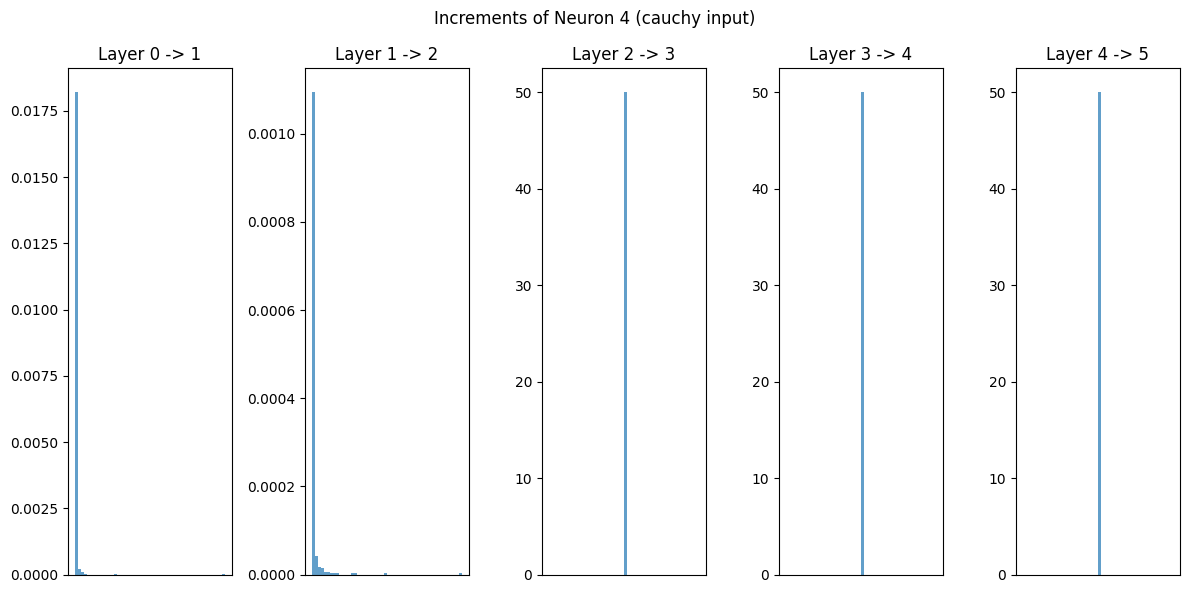

In [68]:
# Example: print alpha values for a few neurons if available
print("\nLoaded alpha values from file:")
for nid, data in saved_results.items():
    alphas = [entry['alpha'] for entry in data if entry['alpha'] is not None]
    print(f"Neuron {nid}: {alphas}")
# Plot histogram of a single neuron's increments across layers
layerwise_increments = [inc[:, neuron_idx].numpy() for inc in increments]

plt.figure(figsize=(12, 6))
for i, layer_inc in enumerate(layerwise_increments[:5]):  # first 5 layers
    plt.subplot(1, 5, i+1)
    plt.hist(layer_inc, bins=50, density=True, alpha=0.7)
    plt.title(f'Layer {i} -> {i+1}')
    plt.xticks([])
plt.suptitle(f'Increments of Neuron {neuron_idx} ({input_type} input)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i, layer_inc in enumerate(layerwise_increments[5:10]):  # first 5 layers
    plt.subplot(1, 5, i+1)
    plt.hist(layer_inc, bins=50, density=True, alpha=0.7)
    plt.title(f'Layer {i} -> {i+1}')
    plt.xticks([])
plt.suptitle(f'Increments of Neuron {neuron_idx} ({input_type} input)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i, layer_inc in enumerate(layerwise_increments[10:15]):  # first 5 layers
    plt.subplot(1, 5, i+1)
    plt.hist(layer_inc, bins=50, density=True, alpha=0.7)
    plt.title(f'Layer {i} -> {i+1}')
    plt.xticks([])
plt.suptitle(f'Increments of Neuron {neuron_idx} ({input_type} input)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i, layer_inc in enumerate(layerwise_increments[15:20]):  # first 5 layers
    plt.subplot(1, 5, i+1)
    plt.hist(layer_inc, bins=50, density=True, alpha=0.7)
    plt.title(f'Layer {i} -> {i+1}')
    plt.xticks([])
plt.suptitle(f'Increments of Neuron {neuron_idx} ({input_type} input)')
plt.tight_layout()
plt.show()



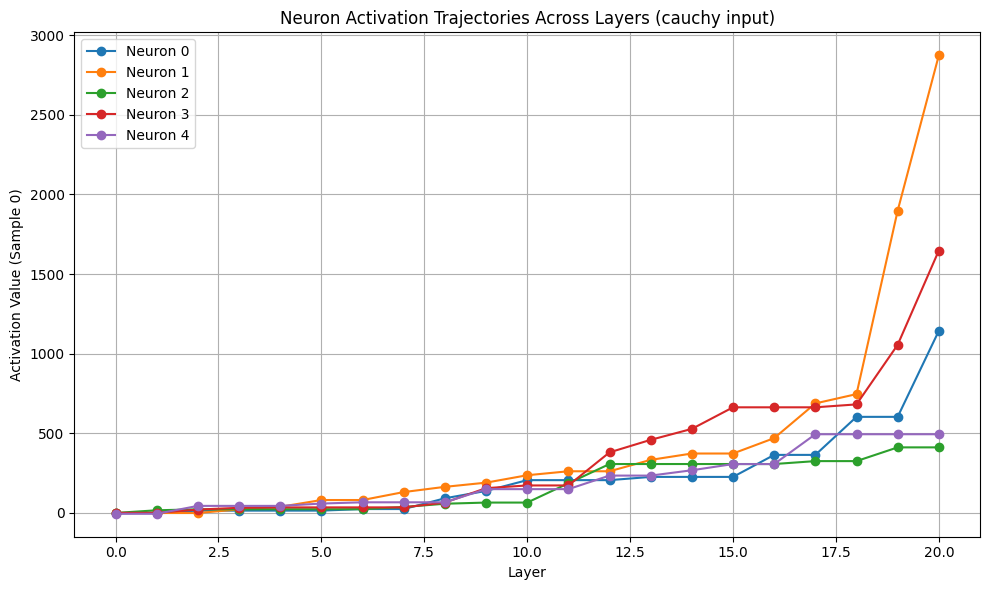

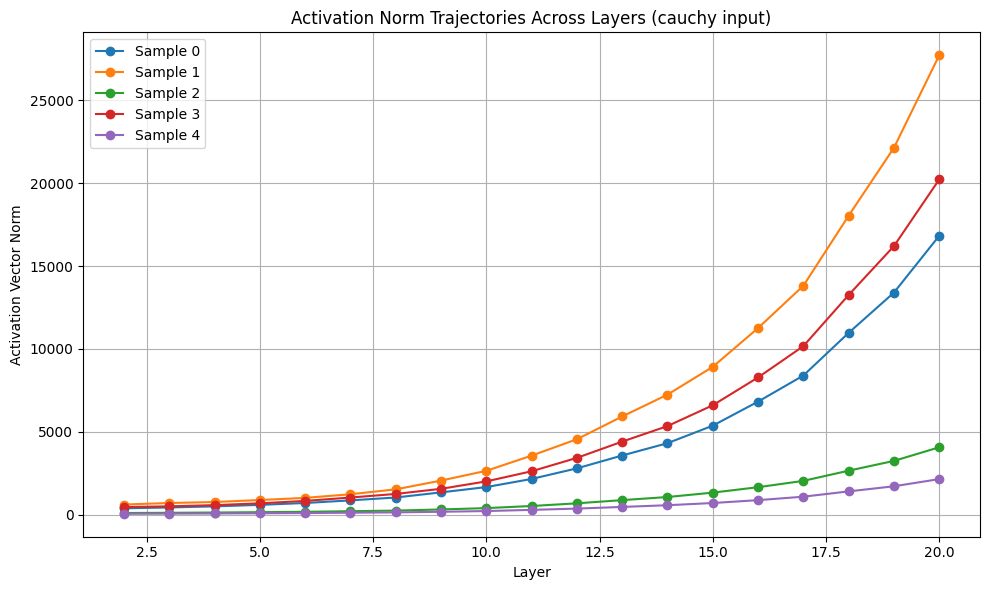

In [ ]:
# Visualize activation trajectories across layers for a few neurons and a sample
sample_idx = 0  # fixed sample index
neuron_indices = [0,1,2,3,4]  # first 5 neurons 

plt.figure(figsize=(10, 6))
for neuron_idx in neuron_indices:
    trajectory = [a[sample_idx, neuron_idx].item() for a in activations]
    plt.plot(range(L+1), trajectory, marker='o', label=f'Neuron {neuron_idx}')

plt.xlabel('Layer')
plt.ylabel(f'Activation Value (Sample {sample_idx})')
plt.title(f'Neuron Activation Trajectories Across Layers ({input_type} input)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Track norm of activations across layers for multiple samples
plt.figure(figsize=(10, 6))
for sample_idx in range(5):
    norms = [a[sample_idx].norm().item() for a in activations]
    plt.plot(range(L+1)[2:], norms[2:], marker='o', label=f'Sample {sample_idx}')

plt.xlabel('Layer')
plt.ylabel('Activation Vector Norm')
plt.title(f'Activation Norm Trajectories Across Layers ({input_type} input)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


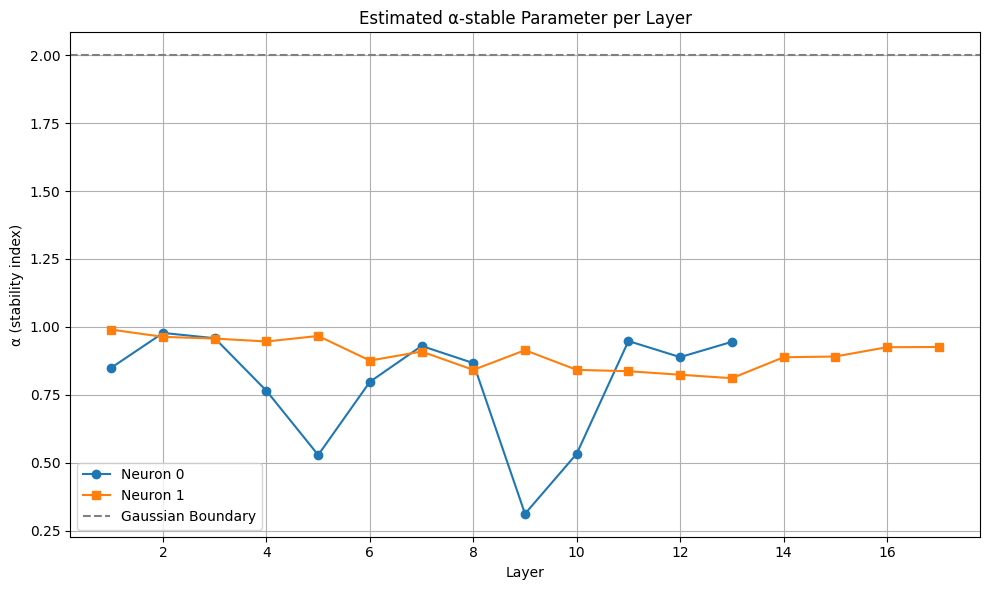

In [ ]:
alphas_n0 = [0.849870694135552, 0.9777381515710937, 0.958205201962781, 0.7644629885046315, 0.5283177377465751, 0.7977927825810842, 0.9298092910015407, 0.8667156232318671, 0.31183125760775054, 0.5329146697420069, 0.947832204053166, 0.8886590627482733, 0.9448957968740179]

alphas_n1 = [0.9898368465054594, 0.9632376290655431, 0.9569181720397708, 0.946269020239614, 0.9665836950182944, 0.8759187959729327, 0.9092834409268173, 0.8416503751492587, 0.9142259114868234, 0.8417371057425422, 0.836755841658231, 0.8237927817716466, 0.811084646578655, 0.8880909868348131, 0.8909278641736676, 0.9250863733403376, 0.9259974839039147]
#alphas_n2 = [1.013781575727002, 2.0, 1.0460600042840051, 2.0, 2.0, 2.0, 1.0571360575394653, 1.9999999999999982, 2.0, 1.0608149292723645, 1.9999999999999982, 2.0, 2.0, 2.0, 1.0569125397825725, 1.1757152389847474, 1.049044818396825, 1.1942949338618325, 1.0618799845986502, 1.1526555042030096]
#alphas_n3 = [0.9595526431050991, 1.9999999999999982, 1.2572848834140045, 1.0541584356194011, 1.0497266084799861, 1.0628681150618857, 1.0510346485772322, 2.0, 1.0705845514378838, 1.9999999999999996, 1.1977916361103615, 1.0829777337236963, 2.0, 1.0837539297163836, 1.0640019441782234, 1.075084722708068, 1.1644579925569432, 1.060690116534173, 2.0, 1.0683746697224015]
#alphas_n4 = [1.1133559094573582, 2.0, 1.9999999999999982, 1.056512125975829, 1.0792394325693435, 1.0516720550914438, 1.0550632736583054, 1.0515167907942429, 1.0750100205073219, 1.0717982770586785, 2.0, 1.065937061406074, 2.0, 2.0, 2.0, 2.0, 1.0607678589325307, 1.2264337354461465, 1.1920069924407137, 1.1427009201712461]




plt.figure(figsize=(10, 6))
plt.plot(range(1, 14), alphas_n0, marker='o', label='Neuron 0')
plt.plot(range(1, 18), alphas_n1, marker='s', label='Neuron 1')
#plt.plot(range(1, 21), alphas_n2, marker='^', label='Neuron 2')
#plt.plot(range(1, 21), alphas_n3, marker='d', label='Neuron 3')
#plt.plot(range(1, 21), alphas_n4, marker='p', label='Neuron 4')
plt.axhline(2.0, color='gray', linestyle='--', label='Gaussian Boundary')
plt.title('Estimated α-stable Parameter per Layer')
plt.xlabel('Layer')
plt.ylabel('α (stability index)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()